In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print ('all liberies imported sucessfully')


all liberies imported sucessfully


### Load the Dataset

In [2]:
df = pd.read_excel('Glucose_Spike_Dataset (1).xlsx')

In [3]:
df.head()

,patient_id,age,gender,bmi,diabetes_type,meal_time,carb_intake,protein_intake,fat_intake,fiber_intake,...,sleep_hours,smoking_status,alcohol_consumption,pre_meal_glucose,post_meal_glucose,glucose_change,glycemic_load,carb_fiber_ratio,meal_risk_score,glucose_spike
0,1127,63,Male,25.318753,Type 2,Snack,206.078625,96.988928,81.332092,19.881550,...,6.038772,Yes,No,80.511484,185.125157,104.613673,139.121175,10.313445,2.057729,1
1,861,43,Female,29.887205,Type 1,Snack,110.277131,41.988332,65.323781,9.660801,...,7.787871,No,No,102.325117,101.612905,-0.712212,80.057182,11.297959,2.153776,0
2,1131,65,Female,21.831540,Type 1,Breakfast,88.692079,74.612428,26.828247,26.701083,...,9.146882,No,No,99.639334,123.456632,23.817298,46.809459,3.309272,1.309858,0
3,1096,56,Male,26.610861,Type 2,Dinner,168.193534,70.944312,58.451133,23.006694,...,5.856119,No,No,116.822669,122.497946,5.675277,127.919532,7.278996,2.061997,0
4,1045,58,Male,26.649132,Type 2,Dinner,93.580856,74.851625,14.576802,19.789018,...,7.327162,Yes,No,99.878155,98.419762,-1.458393,58.098774,4.705152,1.168034,0


In [4]:
df.shape

(5150, 28)

In [5]:
df.isnull().sum()

patient_id                0
age                       0
gender                    0
bmi                       0
diabetes_type             0
meal_time                 0
carb_intake               0
protein_intake            0
fat_intake                0
fiber_intake            309
sugar_intake              0
glycemic_index            0
portion_size              0
water_intake              0
insulin_dose            311
medication_adherence      0
physical_activity         0
stress_level            315
sleep_hours             308
smoking_status            0
alcohol_consumption       0
pre_meal_glucose          0
post_meal_glucose         0
glucose_change            0
glycemic_load             0
carb_fiber_ratio          0
meal_risk_score           0
glucose_spike             0
dtype: int64

In [6]:
df.isnull().sum().sum()

1243

#### We have 1,243 missing values across 4 columns
fiber_Intake - 309

Insulin_Dose - 311

Stress_Level - 315

Sleep_Hours - 308

#### Since they are all Numerical values, we are going to fill the missing values with Median

In [7]:
df['fiber_intake'].fillna(df['fiber_intake'].median(), inplace=True)
df['insulin_dose'].fillna(df['insulin_dose'].median(), inplace=True)
df['stress_level'].fillna(df['stress_level'].median(), inplace=True)
df['sleep_hours'].fillna(df['sleep_hours'].median(), inplace=True)

In [8]:
df.isnull().sum().sum()

0

#### All missing values have been filled, now we check for duplicate rows

In [9]:
df.duplicated().sum()

150

In [10]:
df.drop_duplicates(inplace = True)

In [11]:
df.shape

(5000, 28)

#### Checking for datatypes

In [12]:
df.dtypes

patient_id                int64
age                       int64
gender                   object
bmi                     float64
diabetes_type            object
meal_time                object
carb_intake             float64
protein_intake          float64
fat_intake              float64
fiber_intake            float64
sugar_intake            float64
glycemic_index          float64
portion_size            float64
water_intake            float64
insulin_dose            float64
medication_adherence      int64
physical_activity       float64
stress_level            float64
sleep_hours             float64
smoking_status           object
alcohol_consumption      object
pre_meal_glucose        float64
post_meal_glucose       float64
glucose_change          float64
glycemic_load           float64
carb_fiber_ratio        float64
meal_risk_score         float64
glucose_spike             int64
dtype: object

#### Data type is fine, lets check for outliers

In [13]:
df.describe()

,patient_id,age,bmi,carb_intake,protein_intake,fat_intake,fiber_intake,sugar_intake,glycemic_index,portion_size,...,physical_activity,stress_level,sleep_hours,pre_meal_glucose,post_meal_glucose,glucose_change,glycemic_load,carb_fiber_ratio,meal_risk_score,glucose_spike
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,608.075400,48.271600,27.035933,122.428393,59.924484,49.903338,18.085904,46.058963,59.989490,398.938964,...,45.324094,5.438200,6.504190,110.718330,144.623638,33.905308,73.510259,9.757653,1.802932,0.463400
std,345.254653,17.852473,4.964796,58.100708,24.530463,19.628613,7.681128,24.193595,14.680690,120.078483,...,24.195066,2.780598,1.416156,13.521480,32.432819,29.232684,40.373118,12.314813,0.745169,0.498709
min,1.000000,18.000000,16.000000,10.000000,5.000000,5.000000,2.000000,0.000000,30.000000,100.000000,...,0.000000,1.000000,3.000000,70.000000,70.000000,-57.053540,3.000000,0.265554,0.391785,0.000000
25%,312.000000,33.000000,23.640505,81.294804,43.319018,36.460499,13.127722,29.084532,49.734550,319.043889,...,28.338194,3.000000,5.554744,102.006425,121.947365,12.871209,43.715263,4.143375,1.376630,0.000000
50%,616.000000,48.000000,26.984212,121.862590,59.222908,49.809049,17.983936,45.755805,59.860549,399.370355,...,44.813167,5.000000,6.506330,110.976140,142.974890,32.280502,69.396553,6.752469,1.697013,0.000000
75%,908.250000,64.000000,30.404913,163.924115,76.447576,62.828946,23.085939,62.094440,70.465751,477.841138,...,61.728355,8.000000,7.434354,119.945097,165.519054,52.205397,98.506279,10.445251,2.041712,1.000000
max,1200.000000,79.000000,44.093061,319.606832,148.563508,131.989007,48.209951,131.880984,100.000000,807.294680,...,141.502228,10.000000,10.000000,152.885870,273.804356,161.230116,271.344849,152.193730,9.660761,1.000000


#### Summary of Data Cleaning
.   Filled 1,243 missing values with median

.   Removed 150 duplicate rows

.   Verified data types are correct

.   Checked for outliers, and there was no extreme values that could indicate outliers.

#### Exploratory Data Analysis.
Target Variable Distribution

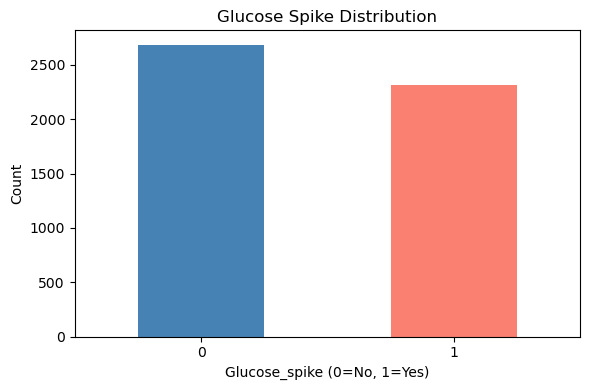

In [14]:
# How balance is our Target Variable?
plt.figure(figsize= (6,4))
df['glucose_spike'].value_counts().plot(kind='bar', color=['steelblue','salmon'])
plt.title('Glucose Spike Distribution')
plt.xlabel('Glucose_spike (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show;

#### Insight
The dataset contains 5,000 patient records with a relatively balanced class distribution. Approximately 2,600 patients (53%) did not experience a glucose spike, while around 2,300 patients (47%) did. This near-equal split is favourable for building a reliable prediction model, as it reduces the risk of the model being biased toward one outcome.

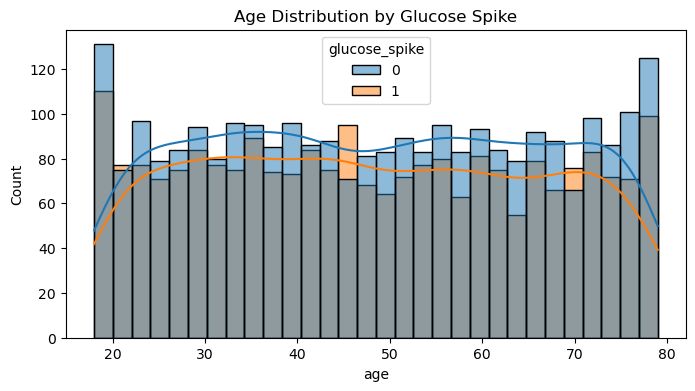

In [15]:
# Age Distribution
plt.figure(figsize=(8,4))
sns.histplot(data=df, x= 'age', hue= 'glucose_spike', bins=30, kde=True)
plt.title('Age Distribution by Glucose Spike')
plt.xlabel('age')
plt.ylabel('Count')
plt.tight_layout
plt.show;

#### Insight 
Glucose spikes were observed across all age groups from 18 to 79 years. Patients in the 40–50 age range showed a higher proportion of glucose spikes, suggesting that middle-aged individuals may be at elevated risk. Older patients around age 70 showed fewer spikes, potentially reflecting better disease management in that group.

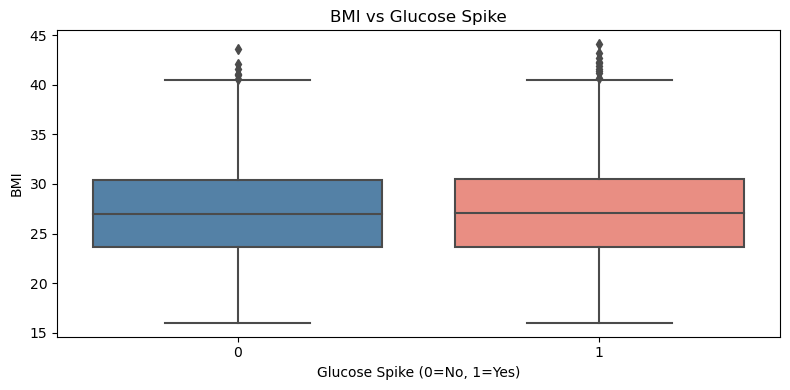

In [16]:
# BMI Distribution
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x='glucose_spike', y='bmi', palette=['steelblue','salmon'])
plt.title('BMI vs Glucose Spike')
plt.xlabel('Glucose Spike (0=No, 1=Yes)')
plt.ylabel('BMI')
plt.tight_layout()
plt.show;

#### Insight
While patients who experienced glucose spikes showed a marginally higher median BMI compared to those who did not, the difference was relatively small. This suggests that BMI alone may not be a strong standalone predictor of glucose spikes, and that other factors such as carbohydrate intake, glycemic index, and pre-meal glucose levels may play a more significant role.

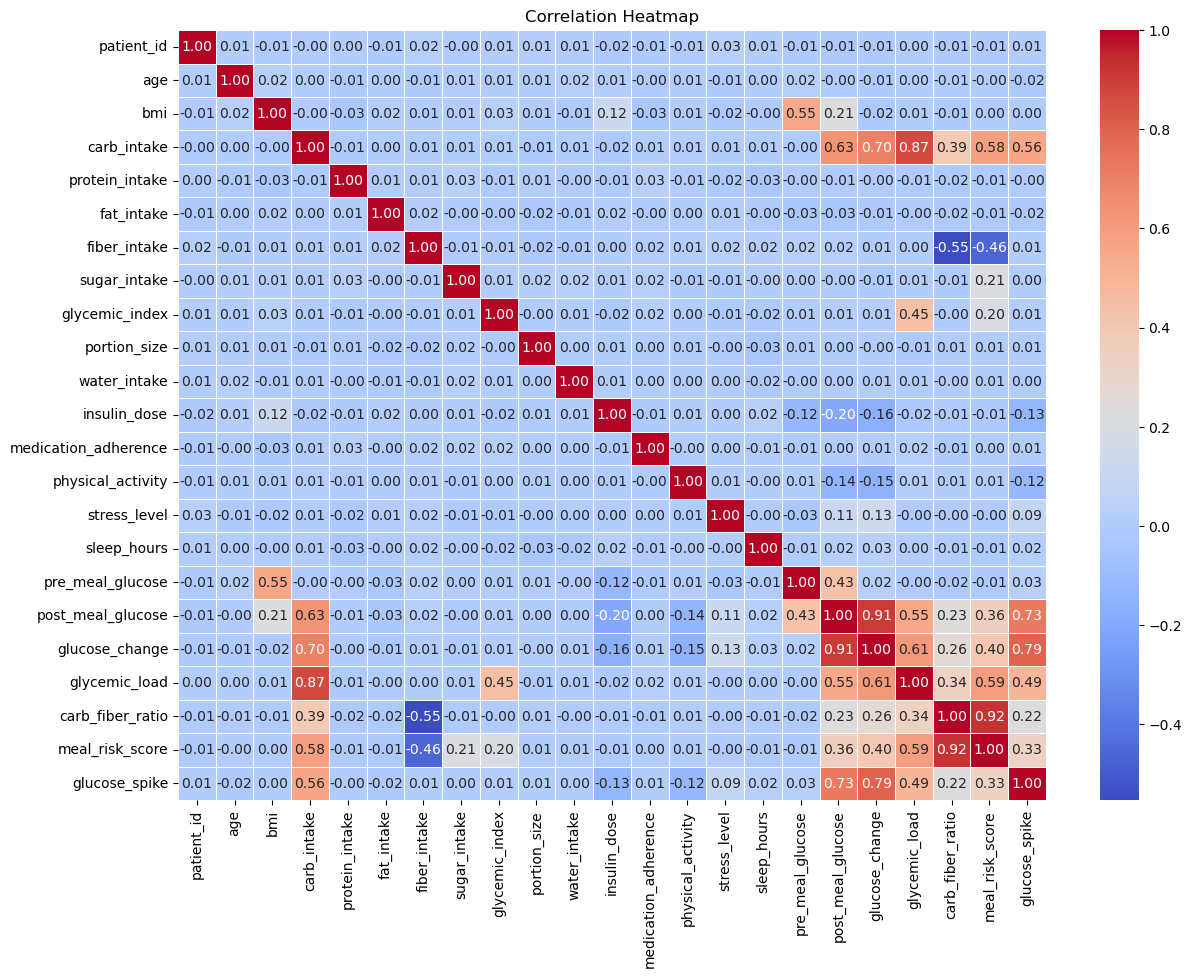

In [17]:
# Correlation Heatmap
plt.figure(figsize=(14,10))
sns.heatmap(df.select_dtypes(include= 'number').corr(),
                      annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout
plt.show;

#### Insight
The correlation heatmap reveals several important relationships in the dataset. Post-meal glucose and glucose change show a strong positive correlation with the target variable (glucose spike), confirming they are key predictors. Carbohydrate intake and glycemic load are also strongly correlated with each other, suggesting multicollinearity that should be considered during feature selection. Most other features show weak correlations with glucose spike, indicating the prediction task will benefit from combining multiple features rather than relying on any single variable.

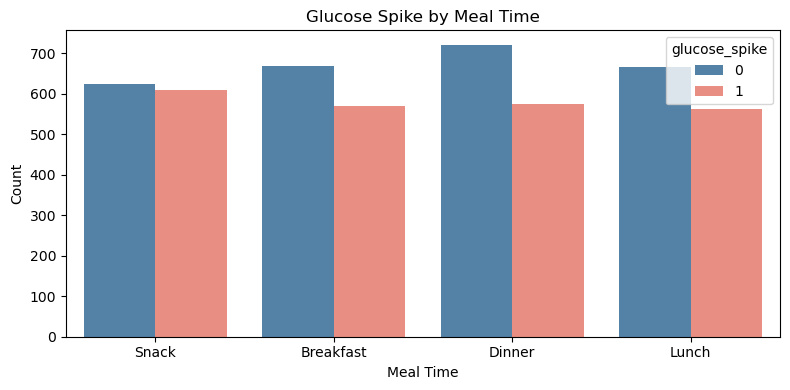

In [18]:
# Glucos Spike by Meal Time
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='meal_time', hue='glucose_spike', palette=['steelblue','salmon'])
plt.title('Glucose Spike by Meal Time')
plt.xlabel('Meal Time')
plt.ylabel('Count')
plt.tight_layout()
plt.show;

#### Insight
Glucose spikes were observed across all meal types. Dinner actually showed the largest gap between non-spike and spike patients, suggesting that despite being a heavy meal, dinner may be better managed among patients in this dataset, possibly due to medication timing or reduced physical activity later in the day. Breakfast and Lunch showed more balanced spike-to-non-spike ratios. Snack time showed nearly equal counts of spike and non-spike patients, making it the meal time with the least predictive separation. Overall, meal time alone shows limited ability to distinguish high-risk patients, reinforcing the need for a multi-feature prediction model.

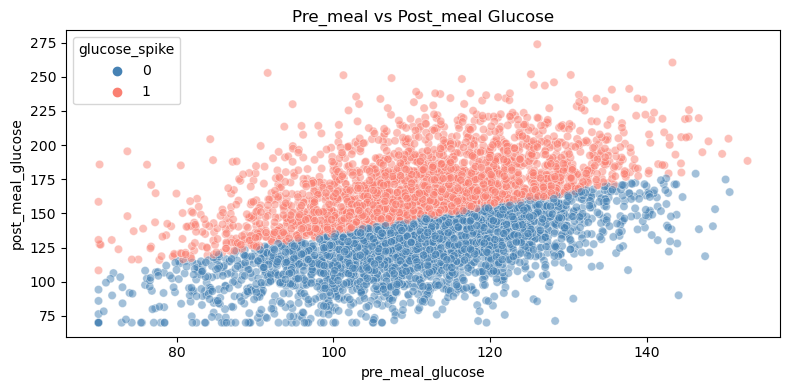

In [19]:
# Pre-Meal Glucose vs Post-meal Glucose
plt.figure(figsize=(8,4))
sns.scatterplot(data=df, x='pre_meal_glucose', y='post_meal_glucose',
                hue='glucose_spike', palette=['steelblue', 'salmon'], alpha=0.5)
plt.title('Pre_meal vs Post_meal Glucose')
plt.xlabel('pre_meal_glucose')
plt.ylabel('post_meal_glucose')
plt.tight_layout()
plt.show;

#### Insight
The scatter plot reveals a clear separation between patients who experienced glucose spikes and those who did not. Patients with glucose spikes consistently recorded higher post-meal glucose levels regardless of their pre-meal glucose reading. As pre-meal glucose increases, post-meal glucose also rises for both groups, but spike patients show a steeper elevation. This confirms that post-meal glucose is one of the strongest indicators of a glucose spike and will likely be an important feature in the prediction model.

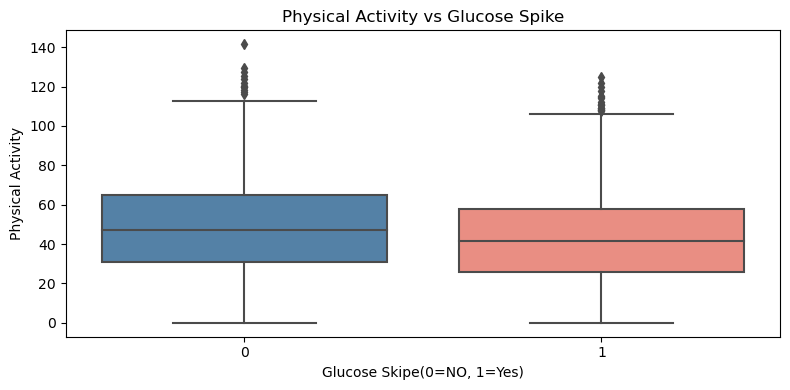

In [20]:
#  Physical Activity vs Glucose Spike
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x='glucose_spike', y='physical_activity',
            palette=['steelblue','salmon'])
plt.title('Physical Activity vs Glucose Spike')
plt.xlabel('Glucose Skipe(0=NO, 1=Yes)')
plt.ylabel('Physical Activity')
plt.tight_layout()
plt.show()


#### Insight
The boxplot shows that patients who did not experience a glucose spike had a slightly higher median physical activity level compared to those who did, which aligns with the established medical understanding that physical activity helps regulate blood glucose levels. However, the difference between the two groups is small, suggesting physical activity alone is not a strong standalone predictor. An outlier was also identified in the no-spike group, where at least one patient recorded an unusually high physical activity level exceeding 140. This reinforces the need for a multi-feature model that combines physical activity with other variables for accurate glucose spike prediction.

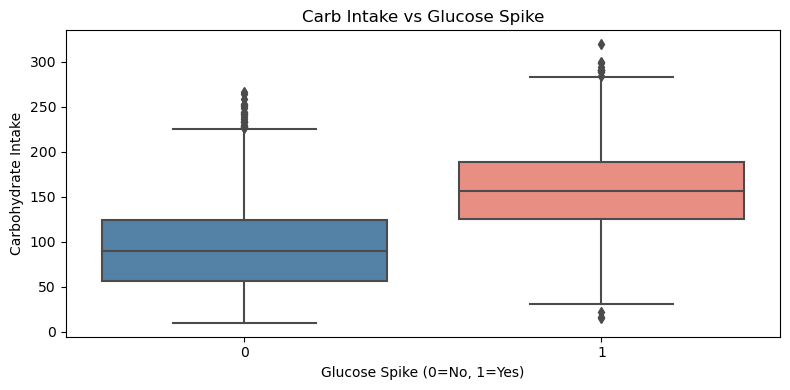

In [21]:
# Carb Intake vs Glucose Spike
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x='glucose_spike', y='carb_intake', 
            palette=['steelblue','salmon'])
plt.title('Carb Intake vs Glucose Spike')
plt.xlabel('Glucose Spike (0=No, 1=Yes)')
plt.ylabel('Carbohydrate Intake')
plt.tight_layout()
plt.show()

#### Insight
The boxplot clearly demonstrates that carbohydrate intake is strongly associated with glucose spikes. Patients who experienced glucose spikes had a significantly higher median carbohydrate intake of approximately 150g compared to around 100g for those who did not spike. The boxes show minimal overlap, indicating that carbohydrate intake is one of the strongest distinguishing features between the two groups. Outliers were present in the glucose spike groups, suggesting some patients consumed unusually high amounts of carbohydrates. This finding strongly supports carbohydrate intake as a key feature in the glucose spike prediction model.

### FEATURE ENGINEERING

In [22]:
# Feature 1: Ratio of post-meal to pre-meal glucose
df['glucose_ratio'] = df['post_meal_glucose'] / df['pre_meal_glucose']

# Feature 2: Combined carb and sugar intake
df['carb_sugar_combined'] = df['carb_intake'] + df['sugar_intake']

# Feature 3: BMI and age interaction
df['bmi_age_interaction'] = df['bmi'] * df['age']

# Confirm new features added
print("New shape:", df.shape)
print("\nNew features:")
print(df[['glucose_ratio', 'carb_sugar_combined', 'bmi_age_interaction']].head())

New shape: (5000, 31)

New features:
   glucose_ratio  carb_sugar_combined  bmi_age_interaction
0       2.299363           233.084609          1595.081430
1       0.993040           184.575759          1285.149815
2       1.239035           136.838999          1419.050082
3       1.048580           224.721456          1490.208224
4       0.985398            93.580856          1545.649651


In [23]:
# Encode categorical columns
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})
df['smoking_status'] = df['smoking_status'].map({'Yes': 1, 'No': 0})
df['alcohol_consumption'] = df['alcohol_consumption'].map({'Yes': 1, 'No': 0})
df['diabetes_type'] = df['diabetes_type'].map({'Type 2': 1, 'Type 1': 0})

# One-hot encode meal_time
df = pd.get_dummies(df, columns=['meal_time'], drop_first=True)

# Confirm
print("Shape after encoding:", df.shape)
print(df.dtypes)




Shape after encoding: (5000, 33)
patient_id                int64
age                       int64
gender                    int64
bmi                     float64
diabetes_type             int64
carb_intake             float64
protein_intake          float64
fat_intake              float64
fiber_intake            float64
sugar_intake            float64
glycemic_index          float64
portion_size            float64
water_intake            float64
insulin_dose            float64
medication_adherence      int64
physical_activity       float64
stress_level            float64
sleep_hours             float64
smoking_status            int64
alcohol_consumption       int64
pre_meal_glucose        float64
post_meal_glucose       float64
glucose_change          float64
glycemic_load           float64
carb_fiber_ratio        float64
meal_risk_score         float64
glucose_spike             int64
glucose_ratio           float64
carb_sugar_combined     float64
bmi_age_interaction     float64
meal_ti

In [ ]:
# Drop columns not needed for modelling
df.drop(columns=['patient_id', 'post_meal_glucose', 'glucose_change', 'glucose_ratio'], inplace=True, errors='ignore')

# Confirm final shape
print("Final dataset shape:", df.shape)
df.head()

Final dataset shape: (5000, 29)


,age,gender,bmi,diabetes_type,carb_intake,protein_intake,fat_intake,fiber_intake,sugar_intake,glycemic_index,...,pre_meal_glucose,glycemic_load,carb_fiber_ratio,meal_risk_score,glucose_spike,carb_sugar_combined,bmi_age_interaction,meal_time_Dinner,meal_time_Lunch,meal_time_Snack
0,63,1,25.318753,1,206.078625,96.988928,81.332092,19.881550,27.005984,67.508785,...,80.511484,139.121175,10.313445,2.057729,1,233.084609,1595.081430,False,False,True
1,43,0,29.887205,0,110.277131,41.988332,65.323781,9.660801,74.298628,72.596360,...,102.325117,80.057182,11.297959,2.153776,0,184.575759,1285.149815,False,False,True
2,65,0,21.831540,0,88.692079,74.612428,26.828247,26.701083,48.146920,52.777497,...,99.639334,46.809459,3.309272,1.309858,0,136.838999,1419.050082,False,False,False
3,56,1,26.610861,1,168.193534,70.944312,58.451133,23.006694,56.527922,76.054964,...,116.822669,127.919532,7.278996,2.061997,0,224.721456,1490.208224,True,False,False
4,58,1,26.649132,1,93.580856,74.851625,14.576802,19.789018,0.000000,62.084038,...,99.878155,58.098774,4.705152,1.168034,0,93.580856,1545.649651,True,False,False


####  Split Data into Train and Test

In [27]:

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split



# Define features (X) and target (y)
X = df.drop(columns=['glucose_spike'])
y = df['glucose_spike']

# Split 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale after splitting
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (4000, 28)
Testing set size: (1000, 28)


#### Train Logistic Regression

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=10000, random_state=42)
lr_model.fit(X_train, y_train)

# Make predictions
lr_pred = lr_model.predict(X_test)

# Evaluate
print("=== Logistic Regression ===")
print("Accuracy:", round(accuracy_score(y_test, lr_pred), 4))
print("Precision:", round(precision_score(y_test, lr_pred), 4))
print("Recall:", round(recall_score(y_test, lr_pred), 4))
print("F1-Score:", round(f1_score(y_test, lr_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, lr_pred), 4))

=== Logistic Regression ===
Accuracy: 0.756
Precision: 0.7571
Recall: 0.7223
F1-Score: 0.7393
ROC-AUC: 0.7546


#### Train Random Forest

In [29]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
rf_pred = rf_model.predict(X_test)

# Evaluate
print("=== Random Forest ===")
print("Accuracy:", round(accuracy_score(y_test, rf_pred), 4))
print("Precision:", round(precision_score(y_test, rf_pred), 4))
print("Recall:", round(recall_score(y_test, rf_pred), 4))
print("F1-Score:", round(f1_score(y_test, rf_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, rf_pred), 4))

=== Random Forest ===
Accuracy: 0.746
Precision: 0.7389
Recall: 0.7265
F1-Score: 0.7326
ROC-AUC: 0.7452


#### Train XGBoost

In [30]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [31]:
from xgboost import XGBClassifier

# Train XGBoost
xgb_model = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Make predictions
xgb_pred = xgb_model.predict(X_test)

# Evaluate
print("=== XGBoost ===")
print("Accuracy:", round(accuracy_score(y_test, xgb_pred), 4))
print("Precision:", round(precision_score(y_test, xgb_pred), 4))
print("Recall:", round(recall_score(y_test, xgb_pred), 4))
print("F1-Score:", round(f1_score(y_test, xgb_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, xgb_pred), 4))

=== XGBoost ===
Accuracy: 0.753
Precision: 0.7437
Recall: 0.739
F1-Score: 0.7414
ROC-AUC: 0.7524


#### Now we have our 3 models, lets do Model Comparison Table

In [32]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [0.756, 0.746, 0.753],
    'Precision': [0.7571, 0.7389, 0.7437],
    'Recall': [0.7223, 0.7265, 0.739],
    'F1-Score': [0.7393, 0.7326, 0.7414],
    'ROC-AUC': [0.7546, 0.7452, 0.7524]
})

print(results.to_string(index=False))

              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression     0.756     0.7571  0.7223    0.7393   0.7546
      Random Forest     0.746     0.7389  0.7265    0.7326   0.7452
            XGBoost     0.753     0.7437  0.7390    0.7414   0.7524


#### Summary of the Three models Comparaison

.   Logistic Regression comes first at 75.6% accuracy

.   XGBoost comes second at 75.3% accuracy  

.   Random Forest comes third at 74.6% accuracy

.   All three models performed similarly, with Logistic Regression slightly ahead after feature scaling

XGBoost will be our final chosen model due to its balance of performance without requiring scaling

#### ROC Curves

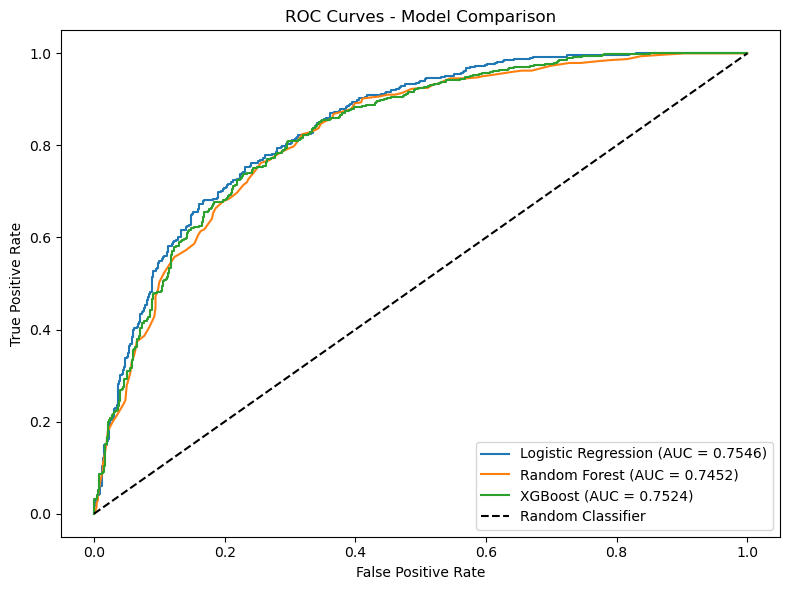

In [33]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

# Logistic Regression ROC
lr_proba = lr_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, lr_proba)
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = 0.7546)')

# Random Forest ROC
rf_proba = rf_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, rf_proba)
plt.plot(fpr, tpr, label=f'Random Forest (AUC = 0.7452)')

# XGBoost ROC
xgb_proba = xgb_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, xgb_proba)
plt.plot(fpr, tpr, label=f'XGBoost (AUC = 0.7524)')

plt.plot([0,1],[0,1],'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison')
plt.legend()
plt.tight_layout()
plt.show()

#### Insight
All three models outperform the random baseline classifier. After removing data leakage, Logistic Regression achieved the highest AUC of 0.7546, followed by XGBoost at 0.7524 and Random Forest at 0.7452. The models perform similarly, with clear separation visible between each curve. XGBoost is selected as the final model due to its robustness and ability to perform well without feature scaling, making it more practical for real-world deployment.

#### Feature Importance

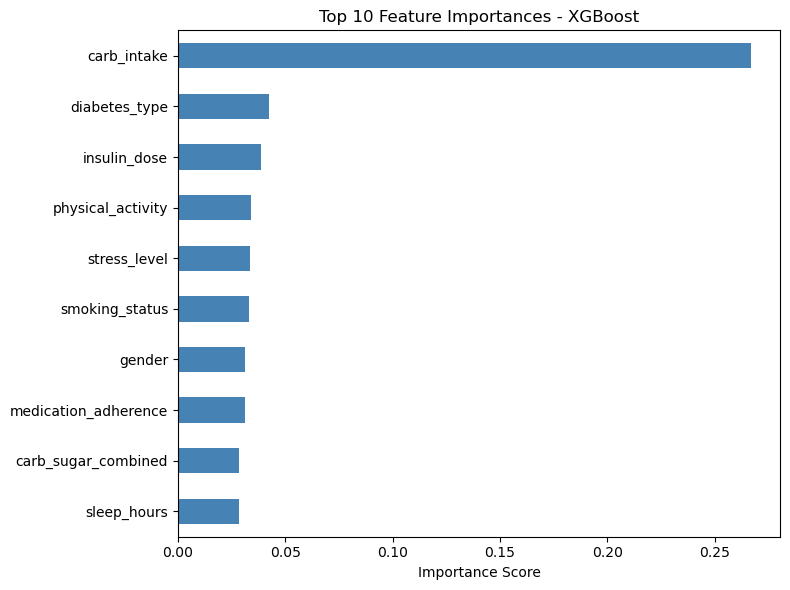

In [34]:


import pandas as pd

feat_importance = pd.Series(xgb_model.feature_importances_, 
                            index=X.columns).sort_values(ascending=False)[:10]

plt.figure(figsize=(8,6))
feat_importance.plot(kind='barh', color='steelblue')
plt.title('Top 10 Feature Importances - XGBoost')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### Insight
Carbohydrate intake emerged as the most dominant predictor of glucose spikes by a significant margin, with an importance score nearly five times higher than the second-ranked feature. 

This strongly confirms the EDA finding that high carbohydrate consumption is the primary driver of glucose spikes. Diabetes type and insulin dose followed as the second and third most important features, reflecting the role of disease severity and medication in glycemic control. 

Physical activity, stress level and smoking status also featured prominently, highlighting the importance of lifestyle factors in glucose management. Notably, the engineered feature carb_sugar_combined appeared in the top 10, validating the feature engineering decisions made earlier in the pipeline. 

These findings suggest that dietary carbohydrate management combined with lifestyle modification represents the most critical intervention strategy for preventing glucose spikes in at-risk patients.